# Comparing Models to Observations

Now that you are familiar with how to use PICASO to generate spectra and interpret spectral features, it's time to start comparing your models to observations! We'll start with one of the simplest approaches: **grid model $\chi^2$ fits** and apply it to the two classes of object Roman-CGI will observe.

- For [**reflected-light**](#RL) targets, we'll use the Batalha+2018 model grid to generate some mock Roman-CGI observations and conduct a grid search to see the extent to which we can recover the true parameters.

- For [**self-luminous**](#SL) targets, we'll use the Sonora-Bobcat model grid and existing infrared observations to investigate the degree to which adding Roman-CGI observations helps constrain target properties beyond what is possible with current data.

NOTE: These procedures are simplified from what would need to be done for real observations in the interest of time. As you work through them, take note of how you might want to make adjustments for working with real observations... you might come up with some fruitful directions for your group project! The supplementary quickstart guides are also available to help you move towards a more comprehensive, realistic data analysis.

----------------------------
## <a id="RL"></a>Reflected light target: generating mock Roman-CGI observations and doing a grid-search with Batalha+2018 models

The grid from Batalha et al. 2018 provides 1D radiative-convective equilibrium T-P profiles for cloudy planets irradiated by a solar-type star. It assumes T_int is fixed to 150 K and that the surface gravity is 25 m^2/s, similar to Jupiter while varying three parameters: metallicity, planet-star separation, and $f_{sed}$.

We will:
1. Pick a "true" planet and compute its noiseless Roman-CGI spectrum
2. Add simple random noise to simulate observations*
3. Construct a 3d grid of [M/H], $d_{sep}$, and $f_{sed}$ (for each model: compute spectra, bin to Roman-CGI observations)
4. Loop through the grid and compute $\chi^2$
5. Analyze quality of results-- how well can you recover the true parameters? what are the degeneracies in this parameter space?

*NOTE: a more realistic approach would use corgi-etc or extract spectra and associated errors from corgi-sim to get a sense of any wavelength dependence to the errors, and what levels of SNR are realistic for each candidate target

First we have to do our package imports, and the usual setting PICASO reference data path

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import os, warnings
warnings.filterwarnings('ignore')
# ── SET YOUR PATHS HERE ──────────────────────────────────────────
PICASO_REFDATA = '/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference'
PYSYN_CDBS = '/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference/stellar_grids'
# ─────────────────────────────────────────────────────────────────
os.environ['picaso_refdata'] = PICASO_REFDATA
os.environ['PYSYN_CDBS'] = PYSYN_CDBS

from picaso import justdoit as jdi
from virga import justdoit as vj   # for recommend_gas, otherwise we would just call virga from picaso

import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd
import astropy.units as u
from tqdm.auto import tqdm

import sys
sys.path.insert(0, '.') # this will help make sure we find roman_tutorial_utils
import roman_tutorial_utils as rtu

The locations of resources we'll use throughout

In [2]:
sonora_db = os.path.join(os.getenv('picaso_refdata'), 'sonora_grids', 'bobcat')
virga_dir = os.path.join(os.getenv('picaso_refdata'), 'virga')
opacity_db = os.path.join(os.getenv('picaso_refdata'),'opacities', 'opacities_roman_school_0.4_7_R10000.db')

Now we load in our opacities

In [3]:
# Optical opacity connection: covers Roman-CGI Bands 1, 3, 4 (0.5–1.0 µm)
opa_opt = jdi.opannection(wave_range=[0.5, 9],filename_db=opacity_db)
print("Optical opannection ready:", opa_opt.nwno, "wavenumber points")
print("molecules loaded are:", opa_opt.molecules)

Optical opannection ready: 26391 wavenumber points
molecules loaded are: ['CH4' 'CO' 'CO2' 'CrH' 'FeH' 'H2O' 'H2S' 'HCN' 'K' 'MgH' 'NH3' 'Na' 'PH3'
 'SiO' 'TiO' 'VO']


### Steps 1+2: Generate the "True" Spectrum and Mock Roman-CGI Observations

We pick a specific Batalha+2018 grid point as our synthetic planet, compute its reflected-light spectrum with PICASO, then sample it at the Roman-CGI band passes and add Gaussian noise.

In [ ]:
# ── Fixed physical parameters ────────────────────────────────────────────────
STELLAR_TEFF = 5000.0  # K   — solar analogue host star
STELLAR_LOGG = 4.0     # log g cgs
STELLAR_MH   = 0.0     # [Fe/H] dex

PLANET_MASS  = 1.0     # M_Jupiter 
PLANET_RP    = 1.0     # R_Jupiter
PHASE_RAD    = 0.0     # radians — we'll stick with full phase for speed

# ── "True" planet parameters ─────────────────────────────────────────────────
TRUE_MH   = 1.0   # [M/H] dex — metal-enriched atmosphere
TRUE_SEP  = 1.0   # AU        — inner warm Jupiter
TRUE_FSED = 1     # moderate sedimentation efficiency

#Load atmosphere profile + cloud profile DataFrames for the truth model
pt_true, cld_true = rtu.read_batalha_profile(TRUE_MH, TRUE_SEP, TRUE_FSED)

#Set up a reflected-light PICASO calculation
inputs_true = jdi.inputs()
inputs_true.phase_angle(PHASE_RAD)
inputs_true.gravity(mass=PLANET_MASS, mass_unit=u.Unit('M_jup'),
                    radius=PLANET_RP, radius_unit=u.Unit('R_jup'))
inputs_true.star(opa_opt, STELLAR_TEFF, STELLAR_MH, STELLAR_LOGG,
                 radius=1.0, radius_unit=u.Unit('R_sun'),
                 semi_major=TRUE_SEP, semi_major_unit=u.Unit('au'))
inputs_true.atmosphere(df=pt_true)
inputs_true.clouds(df=cld_true)

#Calculate the "true" reflected-light spectrum in just the optical
spec_true = inputs_true.spectrum(opa_opt, calculation='reflected', full_output=True)

#Extract Roman-CGI band fluxes from the noiseless model
b1_true, b3_true, b4_true = rtu.mimic_roman_cgi_obs(spec_true, 
                                                    spec_key='fpfs_reflected') #we'll work in planet-star flux ratio space

#Pack data from all three Roman-CGI bands into flat arrays: [B1 photometric] + [B3 spectroscopic channels] + [B4 photometric]
wl_mock  = np.concatenate([[b1_true[0]], b3_true[0], [b4_true[0]]])
fpfs_truth = np.concatenate([[b1_true[1]], b3_true[1], [b4_true[1]]])
N_MOCK   = len(wl_mock)

#Add Gaussian noise at SNR = 15 per channel <------- this is much too simplistic!
SNR = 15.0
np.random.seed(3)  # this helps with reproducibility, 
                   # you can try starting with a few different seeds to see how much
                   # data can change within SNR = 15
fpfs_err = fpfs_truth / SNR
fpfs_obs = fpfs_truth + np.random.normal(0, fpfs_err)

#Plot the noiseless true spectrum and the simulated Roman-CGI observations
#as a sanity check
fig, ax = plt.subplots(figsize=(9, 4))

wno_r50, fpfs_r50 = jdi.mean_regrid(spec_true['wavenumber'],
                                     spec_true['fpfs_reflected'], R=50)
ax.plot(1e4 / wno_r50, fpfs_r50, color='steelblue', lw=1.5,
        label='Truth model (R=50)')

ax.errorbar(wl_mock, fpfs_obs, yerr=fpfs_err,
            fmt='o', color='k', ms=5, elinewidth=1.5, capsize=3,
            label=f'Mock Roman-CGI (SNR={SNR:.0f}/channel)', zorder=5)

ymax = max(fpfs_r50.max(), (fpfs_obs + fpfs_err).max()) * 1.35
rtu.format_roman_cgi_spectrum(ax, 0, ymax,
                              ylabel='F$_p$/F$_*$ (reflected)', xlim=(0.50, 0.93))
ax.legend(fontsize=9)
ax.set_title(f'Synthetic planet: [M/H]={TRUE_MH} dex,  $d$={TRUE_SEP} AU,  '
             f'$f_{{\\rm sed}}$={TRUE_FSED}')
plt.tight_layout()
plt.show()

> Looks good!
>
> Note that we are being quite optimistic here... actual Roman-CGI observations will probably have only a subset of the bands, and likely lower SNR. For band 3 spectra there could also be some correlated noise.

### Step 3: Construct the model grid

We will consider a 3D grid of Batalha+2018 models:  

\[M/H] ∈ {0.0, 0.5, 1.0, 1.5} dex × *d* ∈ {0.7, 1.0, 1.5, 2.0, 3.0} AU × $f_{\mathrm{sed}}$ ∈ {0.03, 0.1, 1, 3, 6}   → **100 models** total. 

For each grid point we:

1. Load the pre-computed T-P and cloud profiles with `read_batalha_profile`
2. Run a PICASO reflected-light calculation
3. Sample the model spectrum in the Roman-CGI bandpasses

**Runtime:** ~5-10 minutes 

In [ ]:
# ── Grid definition ──────────────────────────────────────────────────────────
MH_GRID   = [0.0, 0.5, 1.0, 1.5]      # [M/H] dex
SEP_GRID  = [0.7, 1.0, 1.5, 2.0, 3.0] # orbital separation (AU)
FSED_GRID = [0.03, 0.1, 1, 3,6]       # sedimentation efficiency

dims   = (len(MH_GRID), len(SEP_GRID), len(FSED_GRID))
n_pts  = N_MOCK

#prep some storage space for the loop to fill: model fluxes at the same Roman-CGI wavelengths as mock data
grid_models = np.full((*dims, n_pts), np.nan)

print(f"Grid: {len(MH_GRID)} [M/H] × {len(SEP_GRID)} sep × {len(FSED_GRID)} fsed "
      f"= {int(np.prod(dims))} models\n")

#now time to actually fill the grid in
#this outer layer provides us a nice progress bar
with tqdm(total=int(np.prod(dims)), desc='Batalha+2018 reflected-light grid') as pbar: 
    # here is our nested for loop over the grid
    for i, mh in enumerate(MH_GRID):
        for j, sep in enumerate(SEP_GRID):
            for k, fsed in enumerate(FSED_GRID):
                try:
                    # Load T-P + cloud profile 
                    pt_df, cld_df = rtu.read_batalha_profile(mh, sep, fsed)
    
                    # PICASO reflected-light calculation 
                    case = jdi.inputs()
                    case.phase_angle(PHASE_RAD)
                    case.gravity(mass=PLANET_MASS, mass_unit=u.Unit('M_jup'),
                                 radius=PLANET_RP, radius_unit=u.Unit('R_jup'))
                    case.star(opa_opt, STELLAR_TEFF, STELLAR_MH, STELLAR_LOGG,
                              radius=1.0, radius_unit=u.Unit('R_sun'),
                              semi_major=sep, semi_major_unit=u.Unit('au')) # Note: semi_major=d_sep 
                    case.atmosphere(df=pt_df)
                    case.clouds(df=cld_df)
    
                    with warnings.catch_warnings(): #this prevents lots of warnings about small particle sizes from virga
                        warnings.simplefilter('ignore')
                        spec = case.spectrum(opa_opt, calculation='reflected')
    
                    # Sample at Roman-CGI bands (same grid as mock data)
                    b1_m, b3_m, b4_m = rtu.mimic_roman_cgi_obs(
                        spec, spec_key='fpfs_reflected')
                    model_vec = np.concatenate([[b1_m[1]], b3_m[1], [b4_m[1]]])
    
                    if len(model_vec) == n_pts:
                        grid_models[i, j, k, :] = model_vec

                except Exception:
                    pass   # grid_models stays nan → chi² = inf for this point

                pbar.update(1) # for our progress bar

n_ok = np.sum(np.all(np.isfinite(grid_models), axis=-1)) #checks for any failed grid points
print(f"\nSuccessfully computed: {n_ok} / {int(np.prod(dims))} models")

> That took a little while... it is common to use pre-computed spectral grids either made yourself and repurposed for many objects/observing facilities or published by others. If you were using a precomputed spectral grid, you could skip the PICASO spectrum calculation and just jump to binning it to match Roman-CGI observations. PICASO has some built-in functionality for this introduced in quickstart_gridfitter.ipynb

### Steps 4+5: Compute chi2 across grid and analyze results

For RV-detected targets, we won't know the radius, although we will be able to place some prior on it based on the planet's mass measurment. We'll do our fits with a free normalization constant $C$ at each grid point that marginalizes over the unknown radius. 

$$\qquad \chi^2_\nu = \frac{1}{N-1} \sum_i \frac{(d_i - C \, m_i)^2}{\sigma_i^2}$$

$$C = \frac{\sum_i \, d_i \, m_i \, / \sigma_i^2}{\sum_i \, m_i^2 \, / \sigma_i^2}$$ 


The shape of the **albedo spectrum** — governed by molecular absorption features and cloud scattering — will be what discriminates between grid points. Note that this comes at the expense of removing some of the information about the planet-star separation since: 

$$F_{planet}(\lambda)/F_{star}(\lambda) = \big(\frac{R_{planet}}{d}\big)^2 ~\times~ a(\lambda, \alpha)  $$

We are essentially setting $ C = \big(\frac{R_{planet}}{d}\big)^2$. 

In [ ]:
# ── Chi-squared with analytic normalization marginalization ──────────────────

#set up some storage for chi^2 and C across the grid
chi2   = np.full(dims, np.inf)
C_grid = np.zeros(dims)

#loop through the binned Batalha+2018 grid
for i in range(len(MH_GRID)):
    for j in range(len(SEP_GRID)):
        for k in range(len(FSED_GRID)):
            m = grid_models[i, j, k, :]
            if np.any(~np.isfinite(m)):
                continue
            C = (np.sum(fpfs_obs * m / fpfs_err**2) /
                 np.sum(m**2      / fpfs_err**2))
            resid = fpfs_obs - C * m
            chi2  [i, j, k] = np.sum(resid**2 / fpfs_err**2) / (n_pts - 1)
            C_grid[i, j, k] = C

# locate the Best-fit location
best_idx   = np.unravel_index(np.nanargmin(chi2), dims)
best_mh    = MH_GRID  [best_idx[0]]
best_sep   = SEP_GRID [best_idx[1]]
best_fsed  = FSED_GRID[best_idx[2]]
C_best     = C_grid[best_idx]
best_model = grid_models[best_idx]

print("─" * 45)
print(f"  True parameters:  [M/H]={TRUE_MH:4.1f}  a={TRUE_SEP:.1f} AU  fsed={TRUE_FSED}")
print(f"  Best-fit:         [M/H]={best_mh:4.1f}  a={best_sep:.1f} AU  fsed={best_fsed}")
print(f"  Best-fit χ²_ν  = {chi2[best_idx]:.3f}")
print(f"  Scaling C       = {C_best:.3f}   (ideal = 1.0 for same Rp, distance)")
print("─" * 45)

In [ ]:
# ── Chi-squared maps (3 projections, each marginalised over the third axis) ──
mh_arr   = np.array(MH_GRID)
sep_arr  = np.array(SEP_GRID)
fsed_arr = np.array(FSED_GRID)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# [M/H] vs separation  (min over fsed)
rtu.plot_chi2_grid(axes[0],
                   chi2.min(axis=2), mh_arr, sep_arr,
                   '[M/H] (dex)', 'Separation (AU)',
                   '[M/H] vs Separation\n(min over fsed)',
                   TRUE_MH, TRUE_SEP)

# [M/H] vs fsed  (min over separation)
rtu.plot_chi2_grid(axes[1],
                   chi2.min(axis=1), mh_arr, fsed_arr,
                   '[M/H] (dex)', '$f_{\\rm sed}$',
                   '[M/H] vs $f_{\\rm sed}$\n(min over separation)',
                   TRUE_MH, TRUE_FSED)

# separation vs fsed  (min over [M/H])
rtu.plot_chi2_grid(axes[2],
                   chi2.min(axis=0), sep_arr, fsed_arr,
                   'Separation (AU)', '$f_{\\rm sed}$',
                   'Separation vs $f_{\\rm sed}$\n(min over [M/H])',
                   TRUE_SEP, TRUE_FSED)

plt.suptitle(f'Roman-CGI grid fit — χ² maps  '
             f'(truth: [M/H]={TRUE_MH}, $a$={TRUE_SEP} AU, '
             f'$f_{{\\rm sed}}$={TRUE_FSED},  SNR={SNR:.0f})',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


> Those are some gnarly degeneracies! We didn't actually recover the true parameters with the minimum chi^2, but within the first sigma contour we are in agreement. 

In [ ]:
# ── Best-fit spectrum vs mock observations ───────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax, ax_res = axes

# Noiseless truth
wno_r50, fpfs_r50 = jdi.mean_regrid(spec_true['wavenumber'],
                                    spec_true['fpfs_reflected'], R=50)
ax.plot(1e4 / wno_r50, fpfs_r50, color='steelblue', lw=1.5, alpha=0.8,
        label='Truth (noiseless)')

# Mock observations
ax.errorbar(wl_mock, fpfs_obs, yerr=fpfs_err,
            fmt='o', color='k', ms=5, elinewidth=1.5, capsize=3, zorder=5,
            label=f'Mock Roman-CGI (SNR={SNR:.0f})')

# Best-fit scaled model
ax.plot(wl_mock, C_best * best_model, 'r--', lw=2, zorder=6,
        label=(f'Best fit: [M/H]={best_mh}, $a$={best_sep} AU, '
               f'$f_{{\\rm sed}}$={best_fsed}   '
               f'(χ²_ν = {chi2[best_idx]:.2f})'))

ymax = max(fpfs_r50.max(), (fpfs_obs + fpfs_err).max()) * 1.35
rtu.format_roman_cgi_spectrum(ax, 0, ymax,
                              ylabel='F$_p$/F$_*$ (reflected)', xlim=(0.50, 0.93))
ax.legend(fontsize=8, ncol=1)

# Residuals panel
resid_norm = (fpfs_obs - C_best * best_model) / fpfs_err
ax_res.plot(wl_mock, resid_norm, 'k.', ms=6, alpha=0.7)
ax_res.axhline(0, color='r', lw=1)
ax_res.axhline(+1, color='gray', lw=0.8, ls='--')
ax_res.axhline(-1, color='gray', lw=0.8, ls='--')
ax_res.set_ylabel('Residual (σ)')
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel('Wavelength (µm)')

plt.suptitle('Roman-CGI grid fit: best-fit model vs mock observations', fontsize=11)
plt.tight_layout()
plt.show()

Ideas for further exploration:
- Quick: adjust SNR lower and higher and recompute chi2 loop (no need to re-run the PICASO spectrum calculation and binning in between). what happens to posteriors?
- Quick: recompute the chi2 loop with subsets of the observational coverage, how does this change results?
- Quick: change the seed for the random number generator and look at fit results, do they change significantly?
- Slower: what happens if you drop our analytic C and instead account for consistent separations with models and marginalize over a physically motivated range of radii? what if you limit to a narrow range of separations since we'll have orbital information to constrain this? Can you get away with lower SNR?
- Much Slower: what can you gain by observing at more than one phase angle?


----------------------------
## <a id="SL"></a>Self-luminous Target

Unlike the reflected-light targets, where we only have RV detections, there is already spectral data for the young hot self-luminous targets. We want to investigate the degree to which Roman-CGI observations in the optical give us additional information beyond what is encoded in the IR. 

We'll use $\beta$-Pic b as a case study and carry out a similar procedure to the reflected-light case. This time we'll use Sonora-Bobcat models to generate mock Roman-CGI observations based on parameters that reasonablly fit the IR spectrum. Then we'll compare how IR alone vs IR+Roman-CGI do fitting for T_eff, log(g), f_sed and K_zz, assuming the presence of Fe and Mg2SiO4 clouds.


### Loading Observational IR Data

We'll load observations from the EWI database, which compiles multi-instrument spectra for most directly-imaged substellar companions in a uniform FITS format. This was downloaded as part of the reference data during installation. A function in `roman_tutorial_utils.py` handles file input for us, compiling a dictionary of the information we'll need. Note that is has flux density units of W/m²/µm.

In [4]:
DATA_DIR = os.path.join(os.getenv('picaso_refdata'),'roman_school', 'ewi-data', 'BetaPicb', 'ForMated')

ewi_spec, ewi_phot = rtu.load_ewi_data(DATA_DIR, 
                         exclude=('SINFONI-K4000',)) # our opacity data isn't high enough resolution to analyze this data
print(list(ewi_spec.keys()))
print(list(ewi_phot.keys()))

['GPI', 'GPI_2', 'SPHERE', 'MIRI']
['MagYs', 'NaCoJ', 'NaCoH', 'NaCoKs', 'Clio31', 'Clio33', 'ClioLp', 'NaCoLp', 'NaCo405', 'ClioMp', 'NaCoMp']


In [5]:
print(list(ewi_spec['GPI'].keys()))
print(list(ewi_phot['MagYs'].keys()))

['wav', 'flx', 'err', 'res', 'wno']
['wav', 'main_ins', 'flx', 'err', 'wav_min', 'wav_max']


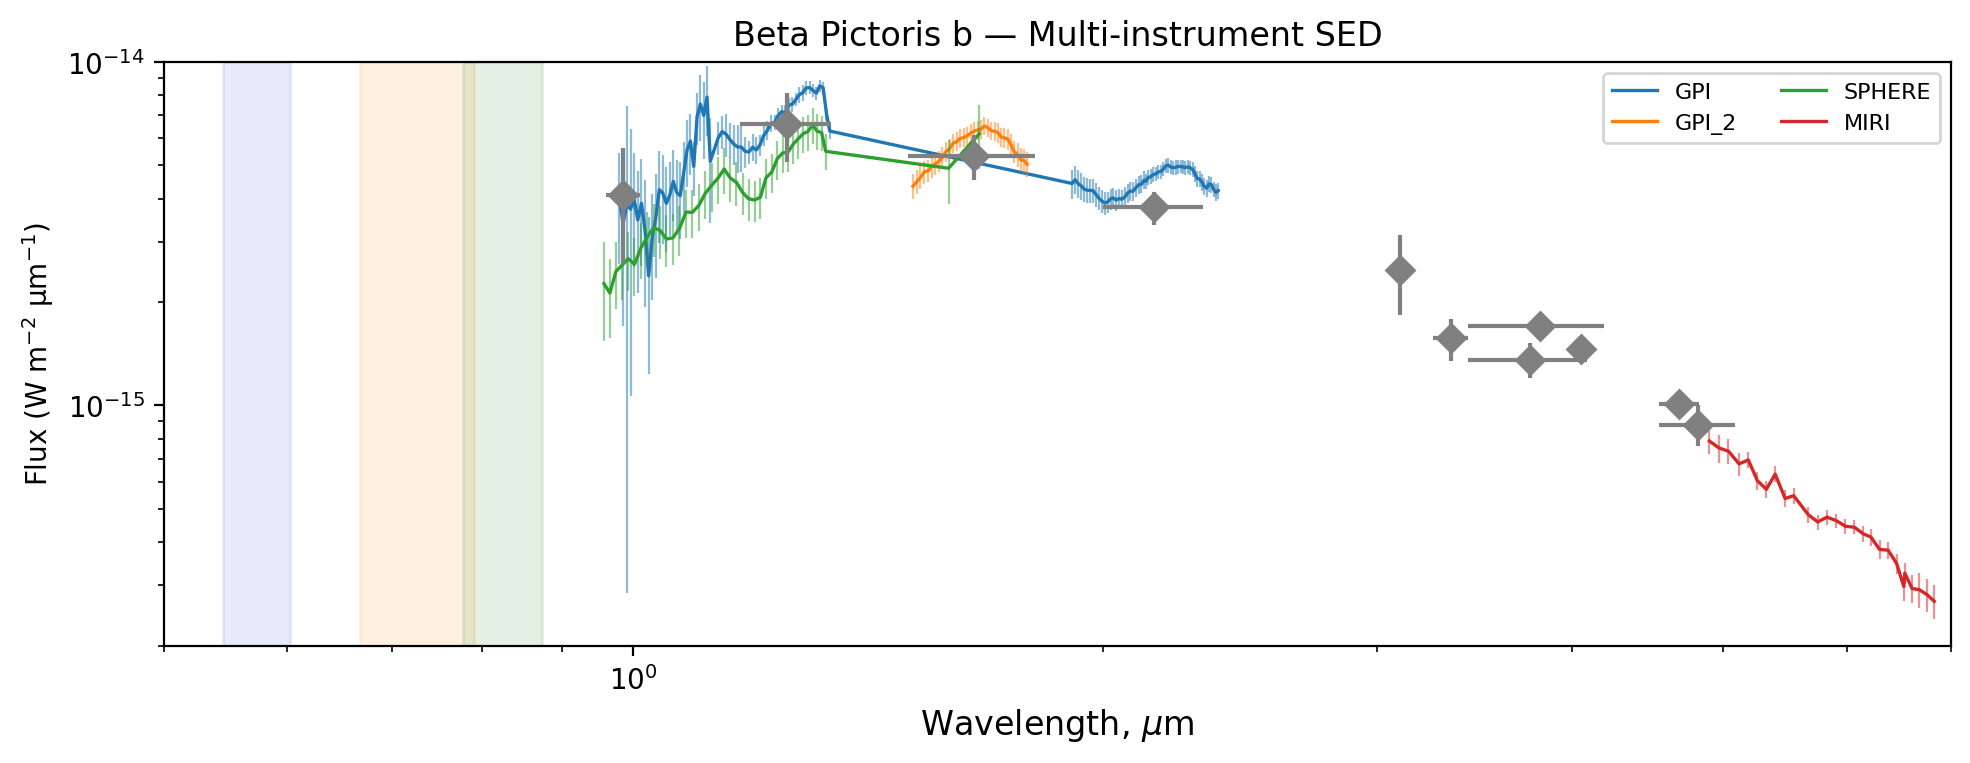

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
all_spec_ins = list(ewi_spec.keys())
all_phot = list(ewi_phot.keys())
colors = plt.cm.tab10.colors

# Spectral channels
for i, label in enumerate(all_spec_ins): 
    d = ewi_spec[label]
    c = colors[i % len(colors)]
    ax.errorbar(d['wav'], d['flx'], yerr=d['err'],
                fmt='none', color=c, elinewidth=0.8, alpha=0.5)
    ax.plot(d['wav'], d['flx'], '-', color=c,
            lw=1.2, label=label)
    
# Photometric points
for i, label in enumerate(all_phot):
    d = ewi_phot[label]
    ax.errorbar(d['wav'], d['flx'], yerr=d['err'], xerr=d['wav']-d['wav_min'],
                fmt='D', color='gray', ms=7, elinewidth=1.5)

ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_title('Beta Pictoris b — Multi-instrument SED')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=8, ncol=2)
rtu.format_roman_cgi_spectrum(ax,2e-16,1e-14,xlim=(0.5,7),ylabel='Flux (W m$^{-2}$ µm$^{-1}$)')
plt.tight_layout()
plt.show()

We'll need opacities that extend out to longer wavelengths for this data

In [7]:
# Load opacity DB over the full range covered by optical + NIR-MIR data (0.5 – 7 µm)
opa = jdi.opannection(wave_range=[0.5, 7.0],filename_db=opacity_db)

### Generating mock Roman-CGI observations

First we have to assume some parameter values for generating a PICASO spectrum. We'll adopt roughly the T_eff and log g from GRAVITY+ 2020, and pick cloud properties that do a reasonable job fitting NIR observations at that T_eff and log g. 

In [8]:
# ── grab nearest Sonora Bobcat grid point to literature Teff/logg ────────────
# GRAVITY+ 2020: Teff ≈ 1724 K, log g ≈ 4.18  (g ≈ 151 m/s²)
TEFF_LIT = 1700    # K     — nearest Sonora grid point to 1724 K
GRAV_LIT = 100     # m/s²  — nearest Sonora grid point to 151 m/s² (log g = 4.25)
LOGG_LIT = round(np.log10(GRAV_LIT * 100), 2)
D_TARGET_PC = 19.44

# the following cloud choices do a reasonable job fitting IR SED
# post-processing this Sonora-Bobcat T-P profile with Eddy-Sed 
# at this temperature range we need to think about silicates and iron
TARGET_CLOUDS = ['Fe', 'Mg2SiO4']
cloud_label_fixed = 'Fe+Mg2SiO4'
kzz_simdata = 1e8
fsed_simdata = 6.0

Generate a spectrum

In [24]:
#calculate spectrum
bd_truth = jdi.inputs(calculation='browndwarf')
bd_truth.gravity(gravity=GRAV_LIT, gravity_unit=u.Unit('m/s**2'))
bd_truth.phase_angle(0)
bd_truth.sonora(sonora_db, TEFF_LIT)
bd_truth.inputs['atmosphere']['profile']['kz'] = kzz_simdata
profile_truth = bd_truth.inputs['atmosphere']['profile']
rec_truth = vj.recommend_gas(profile_truth['pressure'], profile_truth['temperature'], mh=1, mmw=2.2)
active_truth = [g for g in TARGET_CLOUDS if g in rec_truth]
if active_truth:
    bd_truth.virga(active_truth, virga_dir, fsed=fsed_simdata, mh=1, mmw=2.2, verbose=False)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    spec_truth = bd_truth.spectrum(opa)

wno_truth = spec_truth['wavenumber']
wl_truth  = 1e4 / wno_truth
fl_truth  = spec_truth['thermal'] * 1e-7   # convert to W m⁻² µm⁻¹, the units of the ewi data

bin to match ewi data and calculate the normalization factor that minimizes $\chi^2$.

In [10]:
# let's make some flat vectors of all the different instruments' data and
# regrid the PICASO spectrum to match so we can compute the optimal scaling factor C

C_num, C_den = 0.0, 0.0
data_wav = np.array([])
data_flux = np.array([])
data_err = np.array([])
binned_truth_flux = np.array([])

for d in [ewi_spec[key] for key in list(ewi_spec.keys())]:
    model_d = np.empty(len(d['wav']))
    # we can use picaso's mean_regrid to match observations 
    # this time passing the newx kwarg rather than setting R=100 as we did in notebook B
    # note that mean_regrid needs newx to be in ascending wavenumber order
    _, fl_spec = jdi.mean_regrid(wno_truth, 
                                   fl_truth, 
                                   newx=d['wno'][::-1]) 
    model_d = fl_spec[::-1] # but data is in descending wno order, so we'll match that
    C_num += np.sum(d['flx'] * model_d / d['err']**2)
    C_den += np.sum(model_d**2 / d['err']**2)
    data_wav = np.concatenate((data_wav,d['wav']))
    data_flux = np.concatenate((data_flux,d['flx']))
    data_err = np.concatenate((data_err,d['err']))
    binned_truth_flux = np.concatenate((binned_truth_flux,model_d))

for d in [ewi_phot[key] for key in list(ewi_phot.keys())]:
    lmin = d['wav_min']
    lmax = d['wav_max']
    bp_mask = (wl_truth >= lmin) & (wl_truth <= lmax)
    model_d = np.mean(fl_truth[bp_mask])
    C_num += np.sum(d['flx'] * model_d / d['err']**2)
    C_den += np.sum(model_d**2 / d['err']**2)
    data_wav = np.concatenate((data_wav,np.array([d['wav']])))
    data_flux = np.concatenate((data_flux,np.array([d['flx']])))
    data_err = np.concatenate((data_err,np.array([d['err']])))
    binned_truth_flux = np.concatenate((binned_truth_flux,np.array([model_d])))

C_truth = C_num / C_den
binned_truth_flux *= C_truth

As a sanity check, let's see what radius is implied by this normalization constant. As long as data and observations are in same flux density units, the analytic scale factor C minimizes chi-sq such that:

  F_obs = C × F_model   →   C = (R_planet / d)²

Solving for R:   R_planet = d × √C

In [11]:
D_PC     = 19.44              # Hipparcos distance to Beta Pic (pc) is 19.44... but this data seems to be at 10 pc?
PC_TO_M  = 3.085677581e16     # 1 parsec in metres
R_JUP_M  = 7.1492e7           # Jupiter radius in metres

d_m           = D_PC * PC_TO_M
R_planet_m    = d_m * np.sqrt(C_truth) 
R_planet_Rjup = R_planet_m / R_JUP_M

print(R_planet_Rjup)

1.9872165031979108


a little big... but ok!

Now let's bin to Roman-CGI observations and add noise.

In [23]:
SNR_RCGI = 20   # SNR per Roman-CGI channel, feasibility depends on which target considered

fl_truth_scaled = C_truth * fl_truth     # now we have W/m²/µm at Earth rather than surface of planet

# ── Generate mock Roman-CGI data ────────────────────────────────────
spec_dict = {'wavenumber': wno_truth, 'fl_wm2': fl_truth_scaled}
b1_rc, b3_rc, b4_rc = rtu.mimic_roman_cgi_obs(spec_dict, spec_key='fl_wm2')

wl_rcgi       = np.concatenate([[b1_rc[0]], b3_rc[0], [b4_rc[0]]])
flx_rcgi_true = np.concatenate([[b1_rc[1]], b3_rc[1], [b4_rc[1]]])
err_rcgi      = np.abs(flx_rcgi_true) / SNR_RCGI

np.random.seed(7)
flx_rcgi = flx_rcgi_true + np.random.normal(0, err_rcgi, size=len(flx_rcgi_true))
N_RCGI   = len(wl_rcgi)

print(f"Roman-CGI mock: {N_RCGI} data points  (1 B1 + {len(b3_rc[0])} B3 + 1 B4)")

Roman-CGI mock: 11 data points  (1 B1 + 9 B3 + 1 B4)


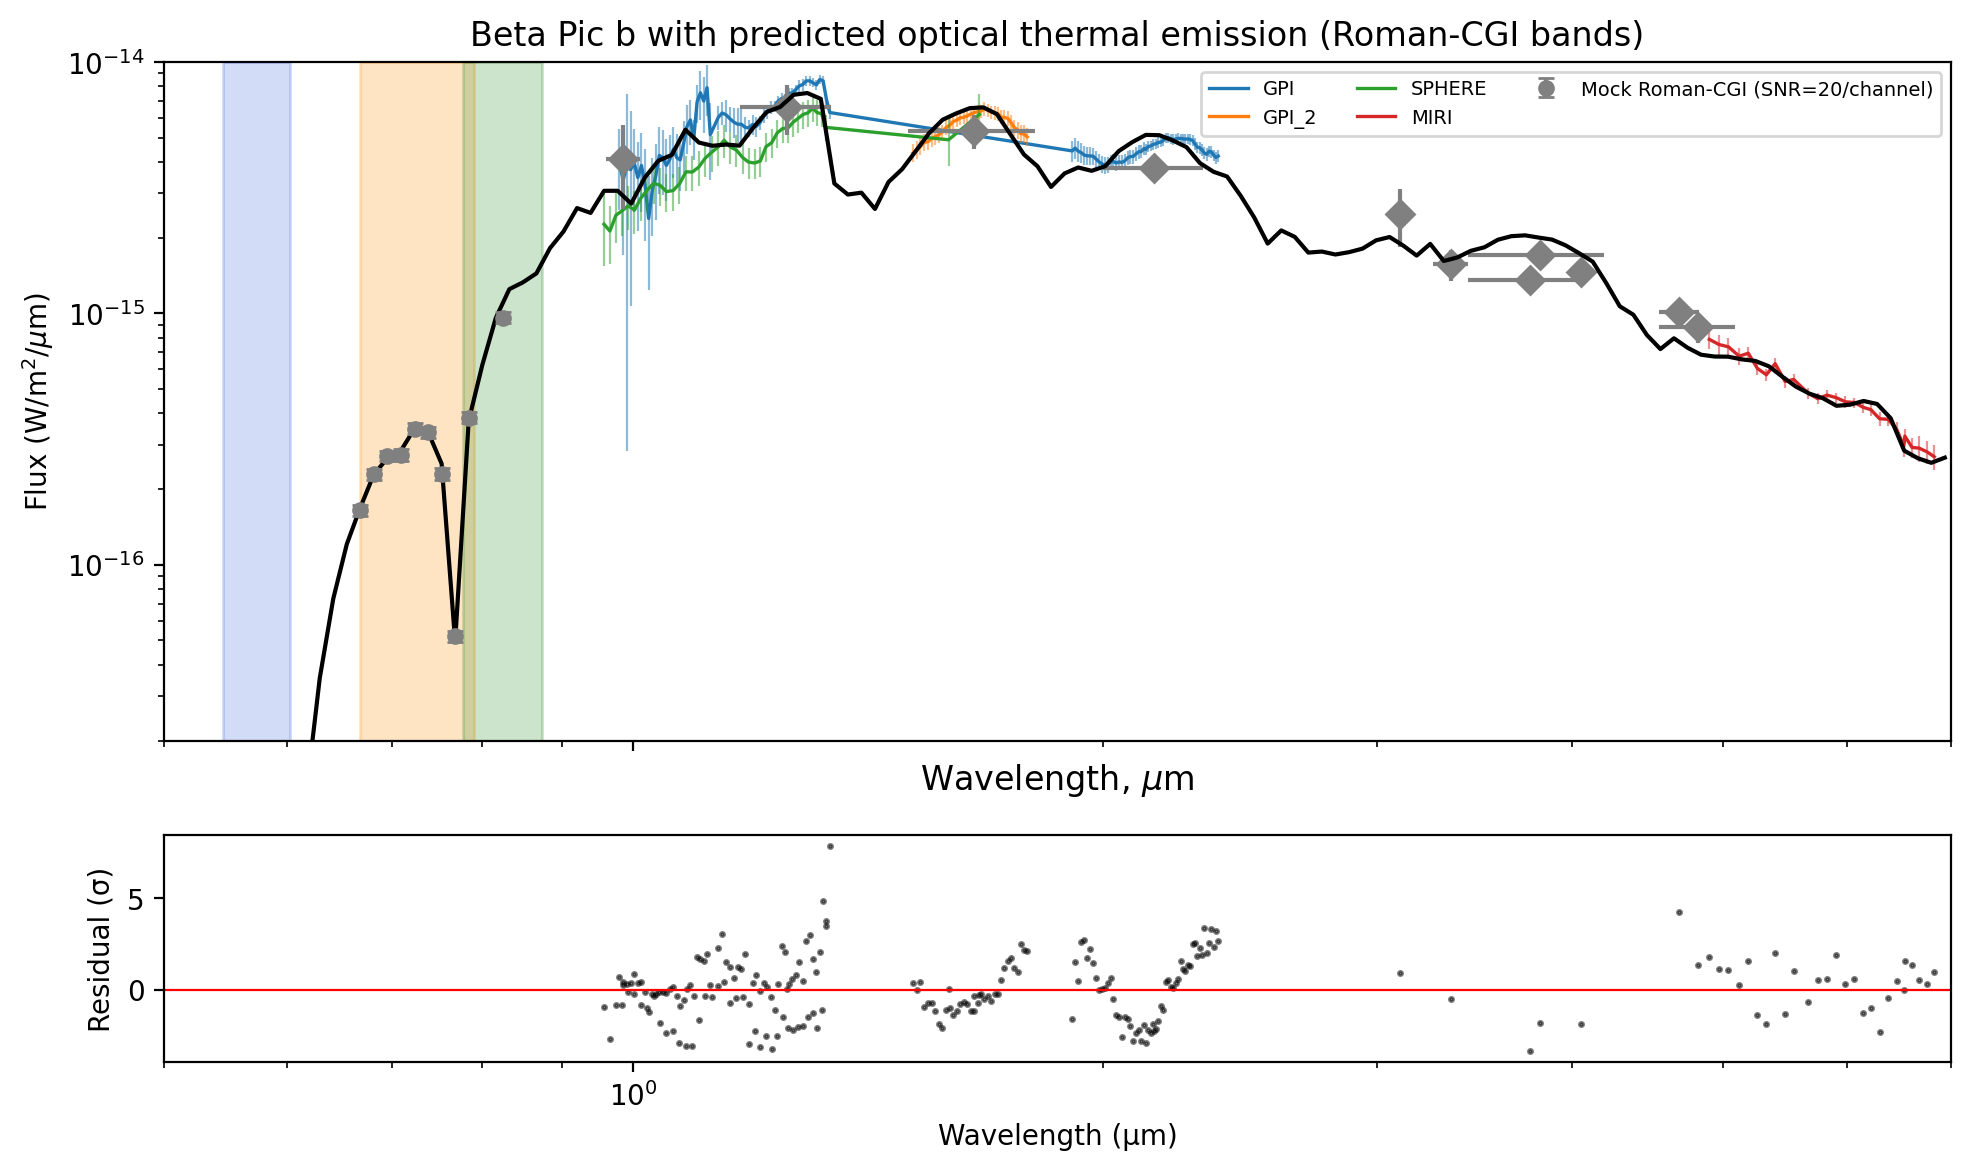

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax, ax_res = axes

# Spectral Data
for i, label in enumerate(all_spec_ins): 
    d = ewi_spec[label]
    c = colors[i % len(colors)]
    ax.errorbar(d['wav'], d['flx'], yerr=d['err'],
                fmt='none', color=c, elinewidth=0.8, alpha=0.5)
    ax.plot(d['wav'], d['flx'], '-', color=c,
            lw=1.2, label=label)
    
# Photometric Data
for i, label in enumerate(all_phot):
    d = ewi_phot[label]
    ax.errorbar(d['wav'], d['flx'], yerr=d['err'], xerr=d['wav']-d['wav_min'],
                fmt='D', color='gray', ms=7, elinewidth=1.5)

ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_title('Beta Pictoris b — Multi-instrument SED')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=8, ncol=2)
rtu.format_roman_cgi_spectrum(ax,2e-16,1e-14,xlim=(0.5,7),ylabel='Flux (W m$^{-2}$ µm$^{-1}$)')

# model used to generate Roman-CGI data
#for plotting, let's get an R=50, closer to observations spectral resolution
wno_truth_scaled_R50, fl_truth_scaled_R50 = jdi.mean_regrid(wno_truth,fl_truth_scaled,R=50)
ax.plot(1e4/wno_truth_scaled_R50, fl_truth_scaled_R50, 'k-', lw=1.5, zorder=5)

# Residuals for NIR, using the regridding we did earlier when we calculated C 
resid = (data_flux - binned_truth_flux) / data_err
ax_res.plot(data_wav, resid, 'k.', ms=3, alpha=0.5)
ax_res.axhline(0, color='r', lw=0.8)
ax_res.set_ylabel('Residual (σ)')
ax_res.set_xlabel('Wavelength (µm)')

# ── Roman-CGI wavlengths -------------------
# Mock observations
ax.errorbar(wl_rcgi, flx_rcgi, yerr=err_rcgi, fmt='o', color='gray',
            ms=5, capsize=3, zorder=5, label=f'Mock Roman-CGI (SNR={SNR_RCGI}/channel)')

ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(fontsize=7, ncol=3)
ax.set_title('Beta Pic b with predicted optical thermal emission (Roman-CGI bands)')
rtu.format_roman_cgi_spectrum(ax,2e-17,1e-14,xlim=(0.5,7),ylabel='Flux (W/m$^2$/$\\mu$m)')

plt.tight_layout()
plt.show()

### Fitting IR data vs. IR+Roman-CGI for Teff, log g, fsed, and Kzz

We search a grid of PICASO/Sonora Bobcat models to find the Teff, log g, and cloud sedimentation efficiency ($f_\mathrm{sed}$) that best match the observed SED. $K_{zz}$ is fixed at the best-fit value found in the 2D fit above (`best_kzz_fixed`).

For each grid point we:
1. Load the Sonora Bobcat T-P profile into a PICASO inputs object
2. Call `virga.recommend_gas` to check which of Fe and Mg₂SiO₄ are thermodynamically stable at this Teff/log g. Only the recommended species are passed to `virga`; if none are recommended the calculation proceeds as a clear atmosphere.
4. Run a PICASO thermal emission spectrum
5. For IR wavelengths: regrid to match observations, we'll use a function set up for this in roman_tutorial_utils
6. For optical wavelengths: regrid to match observations, again with the function set up in roman_tutorial_utils

**Grid**: Teff ∈ {1600, 1700, 1800} K × log g ∈ {4.0, 4.25, 4.5} × $f_\mathrm{sed}$ ∈ {4, 6, 8} × K$_{zz}$ ∈ {1e7, 1e8, 1e9} → **81 models** total.

In [17]:
# ── Grid definition ──────────────────────────────────────────────────────────
TEFF_GRID = [1600, 1700, 1800]   # K
GRAV_GRID = [100, 178, 316]      # m/s²
LOGG_GRID = [round(np.log10(g * 100), 2) for g in GRAV_GRID]
FSED_GRID = [4.0, 6.0, 8.0]      # sedimentation efficiency
KZZ_GRID  = [1e7, 1e8, 1e9]      # cm²/s — vertical mixing

dims = (len(TEFF_GRID), len(GRAV_GRID), len(FSED_GRID), len(KZZ_GRID))
chi2_ir      = np.full(dims, np.inf)
chi2_joint   = np.full(dims, np.inf)
C_grid_ir    = np.zeros(dims)
C_grid_joint = np.zeros(dims)
clouds_recommended = np.zeros(dims, dtype=bool)  # True when ≥1 target cloud is recommended

N_IR    = len(data_wav)   # total IR data points
N_JOINT = N_IR + N_RCGI   # total IR + Roman-CGI data points

with tqdm(total=int(np.prod(dims)), desc='Self-luminous grid') as pbar:
    for i, teff in enumerate(TEFF_GRID):
        for j, grav in enumerate(GRAV_GRID):
            for k, fsed in enumerate(FSED_GRID):
                for l, kzz in enumerate(KZZ_GRID):
                    pbar.update(1)
                    try:
                        bd = jdi.inputs(calculation='browndwarf')
                        bd.gravity(gravity=grav, gravity_unit=u.Unit('m/s**2'))
                        bd.phase_angle(0)
                        bd.sonora(sonora_db, teff)
    
                        # Set Kzz column (needed by virga for particle size calculation)
                        bd.inputs['atmosphere']['profile']['kz'] = kzz
    
                        # Check which target clouds are thermodynamically stable at this T-P
                        profile = bd.inputs['atmosphere']['profile']
                        recommended = vj.recommend_gas(profile['pressure'],
                                                       profile['temperature'],
                                                       mh=1, mmw=2.2)
                        active_clouds = [g for g in TARGET_CLOUDS if g in recommended]
                        clouds_recommended[i, j, k, l] = len(active_clouds) > 0

                        #add a cloud profile to the inputs object if Fe or Mg2SiO4 are stable
                        if clouds_recommended[i, j, k, l]:
                            bd.virga(active_clouds, virga_dir, fsed=fsed, mh=1, mmw=2.2)

                        # calculate spectrum, supressing some warnings
                        with warnings.catch_warnings():
                            warnings.simplefilter('ignore')
                            spec = bd.spectrum(opa, full_output=True)
    
                        # ── regrid to match IR data  ──────────────────────────────────
                        C_ir_num, C_ir_den, C_ir, model_flux = rtu.match_picaso_spec_to_ewi_data(spec, 
                                                                                 ewi_spec, 
                                                                                 ewi_phot)
                        # ── IR-only chi2  ─────────────────────────────────────────────
                        chi2_ir[i, j, k, l] = np.sum(
                                  ((data_flux-model_flux*C_ir) / data_err)**2) / (N_IR - 1)
                        C_grid_ir[i, j, k, l] = C_ir
    
                        # ── regrid to match Roman-CGI optical bands ───────────────────
                        b1, b3, b4 = rtu.mimic_roman_cgi_obs(spec, spec_key='thermal')
                        cgi_vec = np.empty(N_RCGI)
                        cgi_vec[0]    = b1[1]
                        cgi_vec[1:-1] = b3[1]
                        cgi_vec[-1]   = b4[1]
                        cgi_wm2 = cgi_vec * 1e-7   # convert to W m⁻² µm⁻¹
    
                        # ── Joint (IR + optical) chi-sq ────────────────────────────────
                        C_joint_num = C_ir_num + np.sum(flx_rcgi * cgi_wm2 / err_rcgi**2)
                        C_joint_den = C_ir_den + np.sum(cgi_wm2**2 / err_rcgi**2)
                        C_joint = C_joint_num / C_joint_den
    
                        chi2_joint[i, j, k, l] = np.sum(
                                  ((data_flux - C_joint * model_flux) / data_err)**2) 
                        chi2_joint[i, j, k, l] += np.sum(((flx_rcgi - C_joint * cgi_wm2) / err_rcgi)**2)
                        chi2_joint[i, j, k, l]   = chi2_joint[i, j, k, l] / (N_JOINT - 1)
                        C_grid_joint[i, j, k, l] = C_joint

                    except Exception:
                        pass   # chi2 arrays stay inf for this point

n_ok    = int(np.sum(np.isfinite(chi2_joint)))
n_cloud = int(clouds_recommended.sum())
print(f"\nSuccessfully computed : {n_ok} / {int(np.prod(dims))} models")
print(f"Clouds recommended   : {n_cloud} / {int(np.prod(dims))} grid points "
      f"(at least one of Fe/Mg2SiO4 stable)")

Grid: 3 Teff × 3 log g × 3 fsed × 3 Kzz = 81 models
Data: 229 IR points + 11 Roman-CGI = 240 total



Sonora+virga grid:  33%|████████████▋                         | 27/81 [07:15<14:31, 16.13s/it]


Successfully computed : 81 / 81 models
Clouds recommended   : 81 / 81 grid points (at least one of Fe/Mg2SiO4 stable)


In [20]:
# ── Results for IR only ──────────────────────────────────────────────────────
best_ij   = np.unravel_index(np.nanargmin(chi2_ir), dims)
best_teff = TEFF_GRID[best_ij[0]]
best_logg = LOGG_GRID[best_ij[1]]
best_grav = GRAV_GRID[best_ij[1]]
best_fsed = FSED_GRID[best_ij[2]]
best_kzz  = KZZ_GRID [best_ij[3]]
C_best    = C_grid_ir[best_ij]
best_clouds_active = clouds_recommended[best_ij]

print("─" * 45)
print(f"Best-fit Teff IR only  = {best_teff} K     (published: ~1724 K)")
print(f"Best-fit log g IR only = {best_logg}       (published: ~4.18–4.46)")
print(f"Best-fit fsed  IR only = {best_fsed}")
print(f"Best-fit Kzz   IR only = {best_kzz:.0e} cm²/s  (truth: {kzz_simdata:.0e})")
print(f"Clouds active  IR only : {best_clouds_active}  "
      f"({'Fe/Mg2SiO4' if best_clouds_active else 'clear atmosphere — no target clouds stable'})")
print(f"Best-fit χ²    IR only = {chi2_ir[best_ij]:.3f}\n")

# ── Results for joint fit ─────────────────────────────────────────────────────
best_ij_joint   = np.unravel_index(np.nanargmin(chi2_joint), dims)
best_teff_joint = TEFF_GRID[best_ij_joint[0]]
best_logg_joint = LOGG_GRID[best_ij_joint[1]]
best_grav_joint = GRAV_GRID[best_ij_joint[1]]
best_fsed_joint = FSED_GRID[best_ij_joint[2]]
best_kzz_joint  = KZZ_GRID [best_ij_joint[3]]
C_best_joint    = C_grid_joint[best_ij_joint]
best_clouds_active_joint = clouds_recommended[best_ij_joint]

print("─" * 45)
print(f"Best-fit Teff IR+optical  = {best_teff_joint} K  (published: ~1724 K)")
print(f"Best-fit log g IR+optical = {best_logg_joint}    (published: ~4.18–4.46)")
print(f"Best-fit fsed  IR+optical = {best_fsed_joint}")
print(f"Best-fit Kzz   IR+optical = {best_kzz_joint:.0e} cm²/s  (truth: {kzz_simdata:.0e})")
print(f"Clouds active  IR+optical : {best_clouds_active_joint}  "
      f"({'Fe/Mg2SiO4' if best_clouds_active_joint else 'clear atmosphere — no target clouds stable'})")
print(f"Best-fit χ²    IR+optical = {chi2_joint[best_ij_joint]:.3f}")
print("─" * 45)


─────────────────────────────────────────────
Best-fit Teff IR only  = 1800 K     (published: ~1724 K)
Best-fit log g IR only = 4.25       (published: ~4.18–4.46)
Best-fit fsed  IR only = 4.0
Best-fit Kzz   IR only = 1e+08 cm²/s  (truth: 1e+08)
Clouds active  IR only : True  (Fe/Mg2SiO4)
Best-fit χ²    IR only = 2.744

─────────────────────────────────────────────
Best-fit Teff IR+optical  = 1700 K  (published: ~1724 K)
Best-fit log g IR+optical = 4.0    (published: ~4.18–4.46)
Best-fit fsed  IR+optical = 6.0
Best-fit Kzz   IR+optical = 1e+08 cm²/s  (truth: 1e+08)
Clouds active  IR+optical : True  (Fe/Mg2SiO4)
Best-fit χ²    IR+optical = 2.802
─────────────────────────────────────────────


Let's visualize these results with the same 2d $\chi^2$ panels we used for reflected light.

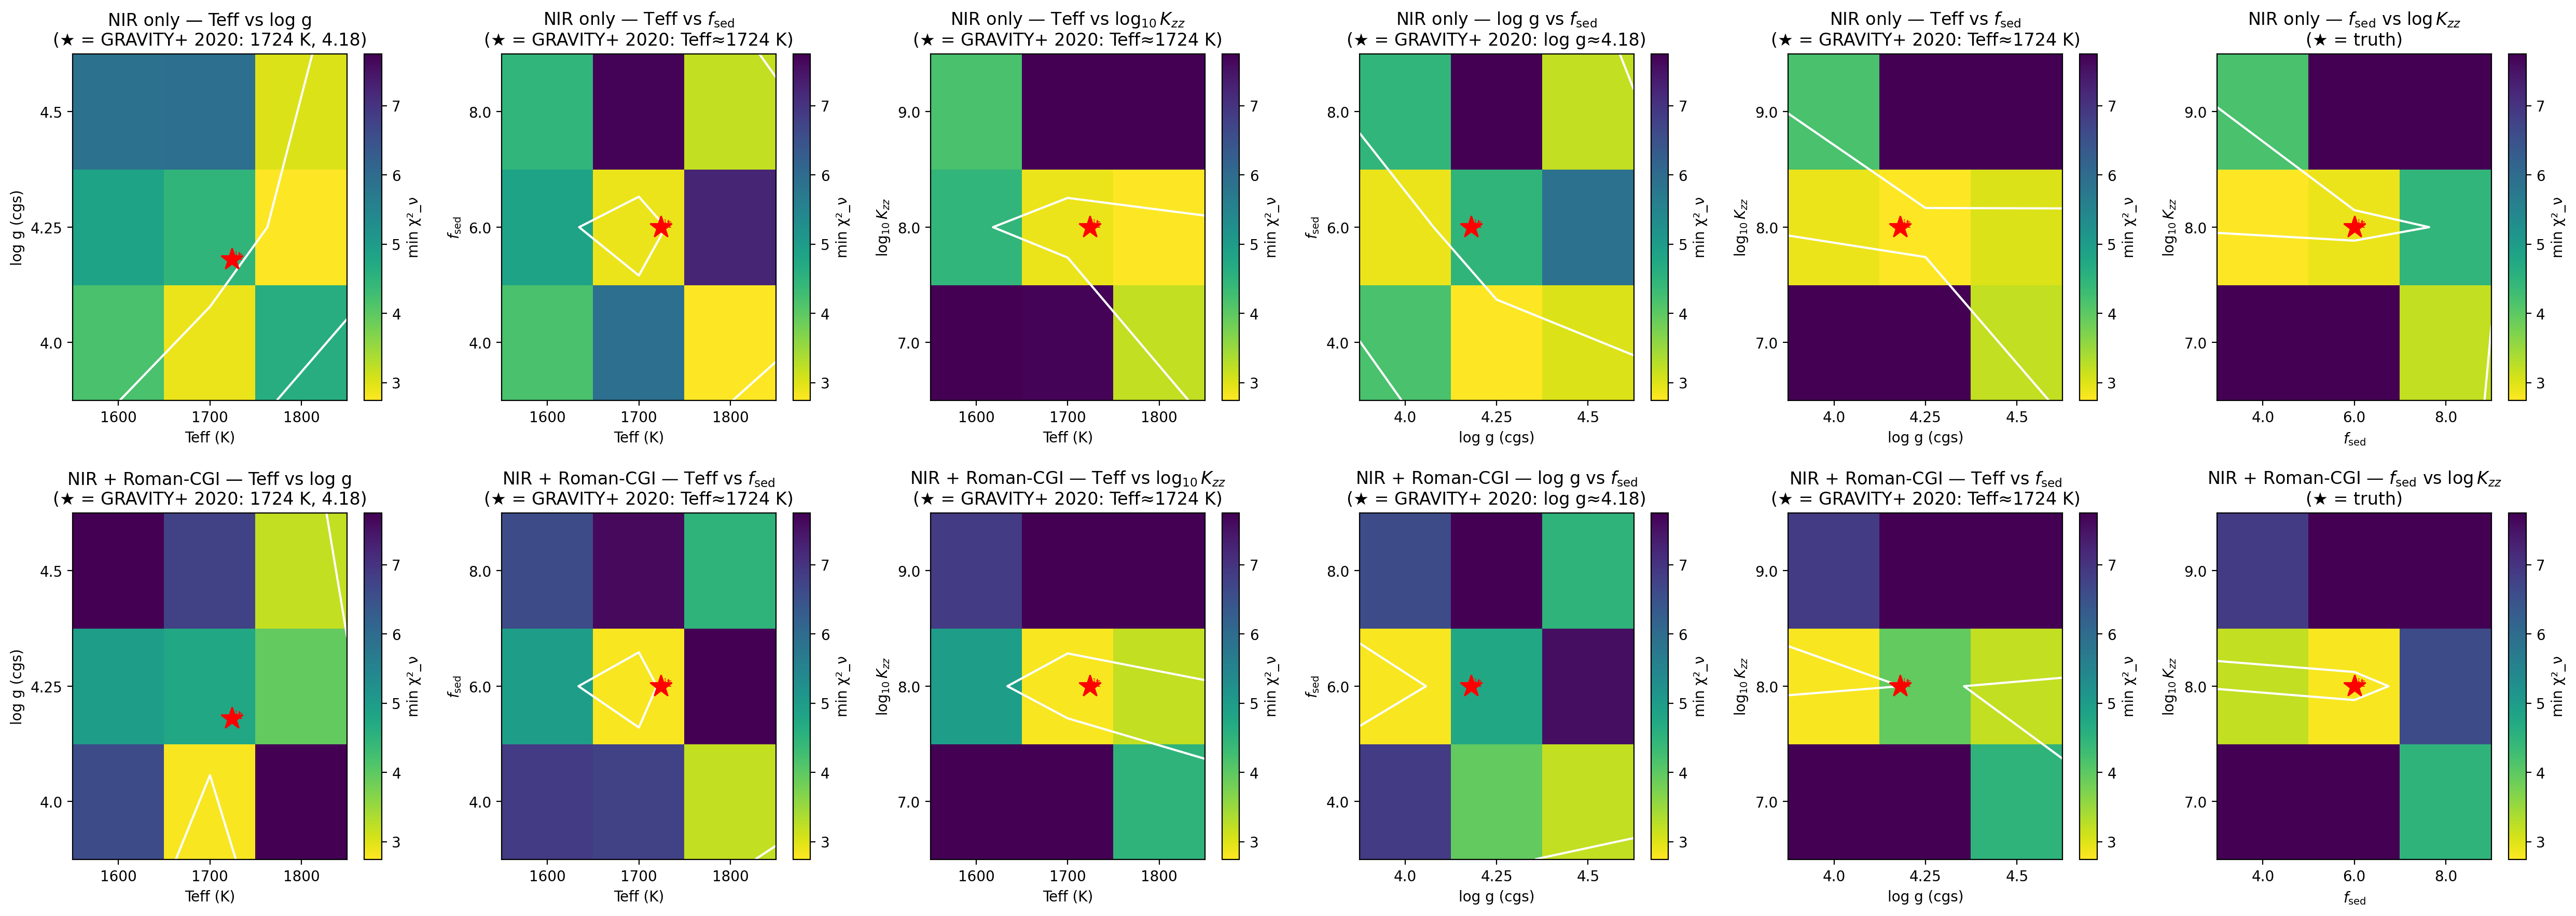

In [22]:
teff_arr    = np.array(TEFF_GRID)
logg_arr    = np.array(LOGG_GRID)
fsed_arr    = np.array(FSED_GRID)
kzz_log_arr = np.log10(np.array(KZZ_GRID))   # plot on log scale

# ── Comparison: NIR-only vs NIR + Roman-CGI chi-squared maps ─────────────────
chi2_min_shared = min(float(np.nanmin(chi2_ir[np.isfinite(chi2_ir)])),
                      float(np.nanmin(chi2_joint[np.isfinite(chi2_joint)])))
min_ir = float(np.nanmin(chi2_ir[np.isfinite(chi2_ir)]))
min_joint = float(np.nanmin(chi2_joint[np.isfinite(chi2_joint)]))

fig, axes = plt.subplots(2, 6, figsize=(25, 9))

# ── Row 1: NIR only ────────────────────────────────────────────────────────────
rtu.plot_chi2_grid(axes[0, 0],
                   chi2_ir.min(axis=(2,3)), teff_arr, logg_arr,
                   'Teff (K)', 'log g (cgs)',
                   'NIR only — Teff vs log g\n(★ = GRAVITY+ 2020: 1724 K, 4.18)',
                   1724, 4.18, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[0, 1],
                   chi2_ir.min(axis=(1,3)), teff_arr, fsed_arr,
                   'Teff (K)', '$f_{\\rm sed}$',
                   'NIR only — Teff vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: Teff≈1724 K)',
                   1724, fsed_simdata, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[0, 2],
                   chi2_ir.min(axis=(1,2)), teff_arr, kzz_log_arr,
                   'Teff (K)', '$\\log_{10} K_{zz}$',
                   'NIR only — Teff vs $\\log_{10} K_{zz}$\n(★ = GRAVITY+ 2020: Teff≈1724 K)',
                   1724, np.log10(kzz_simdata), chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[0, 3],
                   chi2_ir.min(axis=(0,3)), logg_arr, fsed_arr,
                   'log g (cgs)', '$f_{\\rm sed}$',
                   'NIR only — log g vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: log g≈4.18)',
                   4.18, fsed_simdata, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[0, 4],
                   chi2_ir.min(axis=(0,2)), logg_arr, kzz_log_arr,
                   'log g (cgs)','$\\log_{10} K_{zz}$',
                   'NIR only — Teff vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: Teff≈1724 K)',
                   4.18, np.log10(kzz_simdata), chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[0, 5],
                   chi2_ir.min(axis=(0,1)), fsed_arr, kzz_log_arr,
                   '$f_{\\rm sed}$', '$\\log_{10} K_{zz}$',
                   'NIR only — $f_{\\rm sed}$ vs $\\log K_{zz}$\n(★ = truth)',
                   fsed_simdata, np.log10(kzz_simdata), chi2_min=chi2_min_shared)

# ── Row 2: NIR + Roman-CGI ─────────────────────────────────────────────────────
rtu.plot_chi2_grid(axes[1, 0],
                   chi2_joint.min(axis=(2,3)), teff_arr, logg_arr,
                   'Teff (K)', 'log g (cgs)',
                   'NIR + Roman-CGI — Teff vs log g\n(★ = GRAVITY+ 2020: 1724 K, 4.18)',
                   1724, 4.18, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[1, 1],
                   chi2_joint.min(axis=(1,3)), teff_arr, fsed_arr,
                   'Teff (K)', '$f_{\\rm sed}$',
                   'NIR + Roman-CGI — Teff vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: Teff≈1724 K)',
                   1724, fsed_simdata, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[1, 2],
                   chi2_joint.min(axis=(1,2)), teff_arr, kzz_log_arr,
                   'Teff (K)', '$\\log_{10} K_{zz}$',
                   'NIR + Roman-CGI — Teff vs $\\log_{10} K_{zz}$\n(★ = GRAVITY+ 2020: Teff≈1724 K)',
                   1724, np.log10(kzz_simdata), chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[1, 3],
                   chi2_joint.min(axis=(0,3)), logg_arr, fsed_arr,
                   'log g (cgs)', '$f_{\\rm sed}$',
                   'NIR + Roman-CGI — log g vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: log g≈4.18)',
                   4.18, fsed_simdata, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[1, 4],
                   chi2_joint.min(axis=(0,2)), logg_arr, kzz_log_arr,
                   'log g (cgs)','$\\log_{10} K_{zz}$',
                   'NIR + Roman-CGI — Teff vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: Teff≈1724 K)',
                   4.18, np.log10(kzz_simdata), chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[1, 5],
                   chi2_joint.min(axis=(0,1)), fsed_arr, kzz_log_arr,
                   '$f_{\\rm sed}$', '$\\log_{10} K_{zz}$',
                   'NIR + Roman-CGI — $f_{\\rm sed}$ vs $\\log K_{zz}$\n(★ = truth)',
                   fsed_simdata, np.log10(kzz_simdata), chi2_min=chi2_min_shared)

plt.tight_layout()
plt.show()

> More accurate, breaking some degeneracies

Ideas for further exploration:

- adjust SNR for mock Roman-CGI data, what happens?
- add a star to the inputs object and switch from the `'browndwarf'` calculation to `'thermal'`,  so you can get get Fp/Fs. If any points fall below 1e-9, set them as an upper limit in your fitting routine.
- pick one of the other targets from the EWI database and carry out a similar study.
- we have been assuming only white noise, but these spectra often have noise that is correlated in wavelength space. The EWI database includes covariance matrices for some of the observations. Adjust the $\chi^2$ calculation to account for this. 

-----------------

We've worked through both grid generation and $\chi^2$ calculation manually here, but in practice there are lots of pre-computed grids available in the literature. There are also some handy tools for both managing the diverse file fomats of all the grids and how to match them to observations collected from diverse facilities. 

**Grids for brown dwarfs and wide-separation giant planets:**
- Sonora family: Bobcat, Diamondback, Elf Owl, Hummingbird*
- ExoREM

**Grids/Tools for Reflected-light:**

- Batalha+ 2018
- MacDonald
- Cahoy 2010
- Empirical Jupiter+Neptune hybrids

**Tools for grid fitting:**
- species
- SEDA
- ForMosa
- PICASO's built in GridFitter class &larr; see quickstart_gridfitter 

--------------------
The end! 